## Amazon EU BSR Share 분석

In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math
from datetime import date

In [3]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [4]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [8]:
# Top 20 --> Top 10 브랜드 데이터
# 과거 3년월동안 BSR share 기준으로 Top 브랜드 선정

sql = f"""
select * from wook.amz_eu_bsr_shr_daily_acc2
where bsr_date >= '2023-01-01' and bsr_rank_range='Top 50'
"""

df = bqclient.query(sql).to_dataframe()

In [10]:
print(df)

        country   bsr_ctgry        asin  rank    bsr_date        brand  \
0            NL  Mattresses  B0C4YFK2QC    19  2024-05-01  B FURNITURE   
1            FR    Mattress  B07MFQLC74     1  2023-03-10    NATURALEX   
2            BE  Mattresses  B0BHS84NCL     6  2024-11-11       OVILLA   
3            NL  Mattresses  B00XW6SR9U    44  2023-09-13      PROCAVE   
4            NL  Mattresses  B09SV36JQP    37  2025-03-10       Others   
...         ...         ...         ...   ...         ...          ...   
3381263      DE      Chairs  B08GS3729L    26  2023-07-19       Others   
3381264      DE      Chairs  B016QDC2NC    47  2024-01-28       Others   
3381265      DE      Chairs  B00464AJ7U     3  2025-09-13       Others   
3381266      DE      Chairs  B08XTJZ1LS    39  2024-01-29       Others   
3381267      DE      Chairs  B08Y566Y7H    17  2024-10-12       Others   

                        brand_raw  \
0                     B FURNITURE   
1                       NATURALEX   


## 1.ZINUS BSR 점유률

In [17]:
df_2025 = df[df['yr_month'] >= '25-01'].copy()

In [19]:
print(df_2025)

        country   bsr_ctgry        asin  rank    bsr_date      brand  \
2            SE  Mattresses  B0CKZ8T9NS    37  2025-09-02        FDM   
10           UK  Mattresses  B0CJ2873MV    18  2025-01-13     TEQSLI   
11           DE  Mattresses  B0D14M2G6K    33  2025-03-09  VESGANTTI   
14           DE  Mattresses  B07PVJR392    44  2025-04-15        BMM   
16           BE  Mattresses  B0CKZ8XGP9    23  2025-06-22         DM   
...         ...         ...         ...   ...         ...        ...   
3377708      DE      Chairs  B0DG8Q59DV    16  2025-04-26    TECTAKE   
3377709      DE      Chairs  B0CGDDSYHQ    27  2025-01-12     Others   
3377710      DE      Chairs  B0D8L9NKH2    23  2025-02-01     HOMCOM   
3377712      DE      Chairs  B0CW9SSCXF     7  2025-04-11    TECTAKE   
3377717      DE      Chairs  B0F445WKD8    14  2025-05-26     KESSER   

         brand_raw                                              title  \
2              FDM  FDM Select MAX Mattress 140 x 200 cm, Foam

In [23]:
# 1) 전체 row 수
weekly_total = (
    df_2025.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# 2) ZINUS row 수
weekly_zinus = (
    df_2025[df_2025['brand'].str.upper() == 'ZINUS']  # 대소문자 통일
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# 3) 병합
weekly_share = weekly_total.merge(
    weekly_zinus, on=['country', 'bsr_ctgry', 'yr_week'], how='left'
)

# 4) NaN → 0 채우기
weekly_share['zinus_count'] = weekly_share['zinus_count'].fillna(0)

# 5) 점유율 계산
weekly_share['zinus_share'] = weekly_share['zinus_count'] / weekly_share['total_count']

print(weekly_share.head())

  country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0      BE  Bed Frames  Y25 W01          350          2.0     0.005714
1      BE  Bed Frames  Y25 W02          350          3.0     0.008571
2      BE  Bed Frames  Y25 W03          350          4.0     0.011429
3      BE  Bed Frames  Y25 W04          350          3.0     0.008571
4      BE  Bed Frames  Y25 W05          350          2.0     0.005714


In [27]:
# country별, bsr_ctgry별 ZINUS 점유율 평균
avg_share = (
    weekly_share.groupby(['country', 'bsr_ctgry'])['zinus_share']
    .mean()
    .reset_index()
    .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.004643
1       BE  Beds, Frames & Bases         0.003857
2       BE                Chairs         0.000000
3       BE                 Desks         0.000000
4       BE            Mattresses         0.000214
..     ...                   ...              ...
66      UK                 Desks         0.000000
67      UK         Dining Tables         0.002143
68      UK      Mattress Toppers         0.004427
69      UK            Mattresses         0.032637
70      UK       Sofas & Couches         0.000143

[71 rows x 3 columns]


In [29]:
avg_share.to_csv('avg_zinus_share_0930.csv')

## 2. 전체 기간 : 2023년 ~ 평균 BSR 점유율

In [13]:
df1 = df.copy()

In [15]:
# 1) 전체 row 수
weekly_total = (
    df1.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# 2) ZINUS row 수
weekly_zinus = (
    df1[df1['brand'].str.upper() == 'ZINUS']  # 대소문자 통일
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# 3) 병합
weekly_share = weekly_total.merge(
    weekly_zinus, on=['country', 'bsr_ctgry', 'yr_week'], how='left'
)

# 4) NaN → 0 채우기
weekly_share['zinus_count'] = weekly_share['zinus_count'].fillna(0)

# 5) 점유율 계산
weekly_share['zinus_share'] = weekly_share['zinus_count'] / weekly_share['total_count']
print(weekly_share.head())


  country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0      BE  Bed Frames  Y23 W23          150          1.0     0.006667
1      BE  Bed Frames  Y23 W24          350          3.0     0.008571
2      BE  Bed Frames  Y23 W25          350          3.0     0.008571
3      BE  Bed Frames  Y23 W26          350          5.0     0.014286
4      BE  Bed Frames  Y23 W27          350          3.0     0.008571


In [17]:
# country별, bsr_ctgry별 ZINUS 점유율 평균
avg_share = (
    weekly_share.groupby(['country', 'bsr_ctgry'])['zinus_share']
    .mean()
    .reset_index()
    .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.018160
1       BE  Beds, Frames & Bases         0.013091
2       BE                Chairs         0.000000
3       BE                 Desks         0.001124
4       BE            Mattresses         0.007378
..     ...                   ...              ...
66      UK                 Desks         0.003348
67      UK         Dining Tables         0.006437
68      UK      Mattress Toppers         0.001230
69      UK            Mattresses         0.017648
70      UK       Sofas & Couches         0.007497

[71 rows x 3 columns]


In [19]:
avg_share.to_csv('avg_zinus_share_all_0930.csv')

### 주별 지누스 점유율 Heatmap

In [11]:
df1 = df.copy()

# ✅ brand 컬럼 대문자 변환
df1['brand'] = df1['brand'].str.upper()

# ✅ groupby 단위: country, bsr_ctgry, yr_week
# 전체 row 수
weekly_total = (
    df1.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# ZINUS row 수
weekly_zinus = (
    df1[df1['brand'] == 'ZINUS']
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# ✅ 병합 후 점유율 계산
result = pd.merge(
    weekly_total, weekly_zinus,
    on=['country', 'bsr_ctgry', 'yr_week'],
    how='left'
)

# 결측치는 0으로 처리
result['zinus_count'] = result['zinus_count'].fillna(0)

# 점유율 계산
result['zinus_share'] = result['zinus_count'] / result['total_count']

# 보기 좋게 정렬
result = result.sort_values(['country', 'bsr_ctgry', 'yr_week']).reset_index(drop=True)

# 결과 확인
print(result.head(20))


   country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0       BE  Bed Frames  Y23 W23          150          1.0     0.006667
1       BE  Bed Frames  Y23 W24          350          3.0     0.008571
2       BE  Bed Frames  Y23 W25          350          3.0     0.008571
3       BE  Bed Frames  Y23 W26          350          5.0     0.014286
4       BE  Bed Frames  Y23 W27          350          3.0     0.008571
5       BE  Bed Frames  Y23 W28          350          0.0     0.000000
6       BE  Bed Frames  Y23 W29          350          2.0     0.005714
7       BE  Bed Frames  Y23 W30          350          3.0     0.008571
8       BE  Bed Frames  Y23 W31          350          7.0     0.020000
9       BE  Bed Frames  Y23 W32          350         11.0     0.031429
10      BE  Bed Frames  Y23 W33          350          4.0     0.011429
11      BE  Bed Frames  Y23 W34          350         15.0     0.042857
12      BE  Bed Frames  Y23 W35          350         33.0     0.094286
13    

In [13]:
avg_share = (
    result.groupby(['country', 'bsr_ctgry'], as_index=False)['zinus_share']
          .mean()
          .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)
avg_share.to_csv('temp0002_0925.csv')

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.017743
1       BE  Beds, Frames & Bases         0.012963
2       BE                Chairs         0.000000
3       BE                 Desks         0.001133
4       BE            Mattresses         0.007439
..     ...                   ...              ...
66      UK                 Desks         0.003372
67      UK         Dining Tables         0.006482
68      UK      Mattress Toppers         0.001254
69      UK            Mattresses         0.017468
70      UK       Sofas & Couches         0.007549

[71 rows x 3 columns]


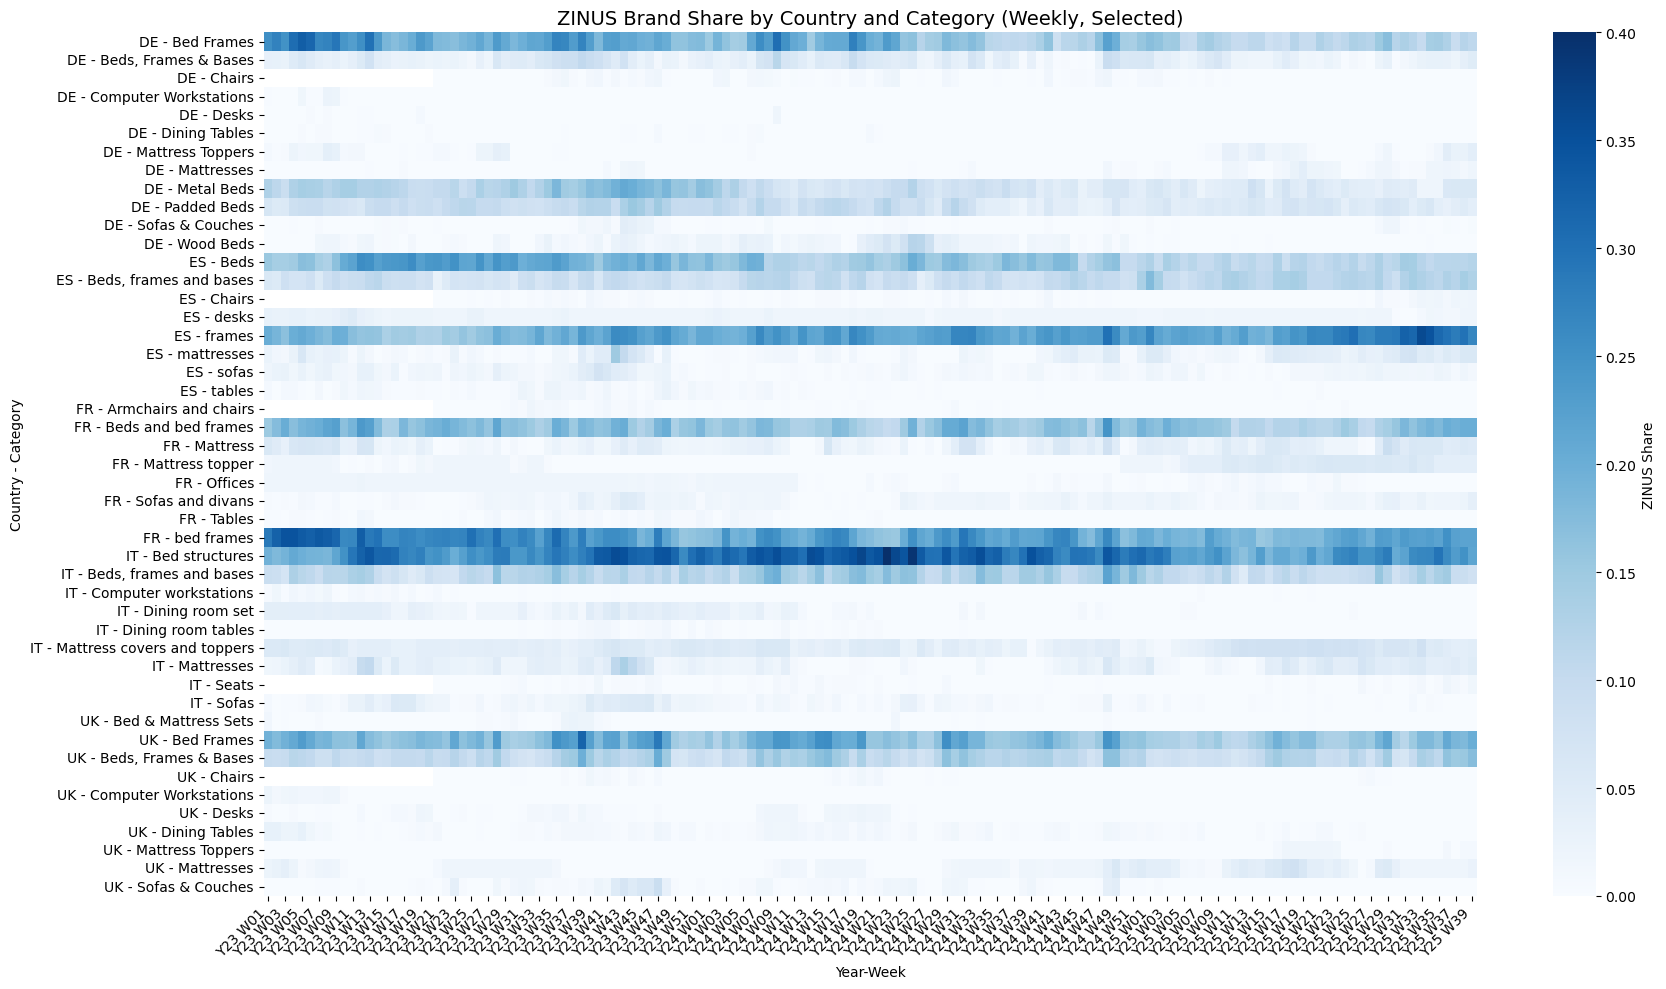

In [15]:

# ✅ 대상 국가만 필터링
target_countries = ["UK", "IT", "FR", "ES", "DE"]
filtered = result[result['country'].isin(target_countries)].copy()

# ✅ 제외할 국가-카테고리 정의
exclude_pairs = [
    #("UK", "Bed Frames"),
    ("IT", "Beds"),
    #("IT", "Bed structures"),
    ("FR", "Beds"),
    #("FR", "bed frames"),
    ("ES", "slatted bed bases"),
    ("ES", "Beds, structures and bases"),
    ("ES", "bed bases"),
    ("DE", "Slatted Divan Bases & Foundations")
]

# ✅ 제외 조건 적용
for c, cat in exclude_pairs:
    filtered = filtered[~((filtered['country'] == c) & (filtered['bsr_ctgry'] == cat))]

# ✅ Pivot 테이블 생성
pivot_table = filtered.pivot_table(
    index=['country', 'bsr_ctgry'],
    columns='yr_week',
    values='zinus_share',
    aggfunc='mean'
)

# 보기 좋게 인덱스 정리
pivot_table.index = [f"{c} - {cat}" for c, cat in pivot_table.index]

# ✅ 히트맵 그리기
plt.figure(figsize=(18, 10))
sns.heatmap(
    pivot_table,
    cmap="Blues",
    annot=False,
    cbar_kws={'label': 'ZINUS Share'}
)

plt.title("ZINUS Brand Share by Country and Category (Weekly, Selected)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Country - Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

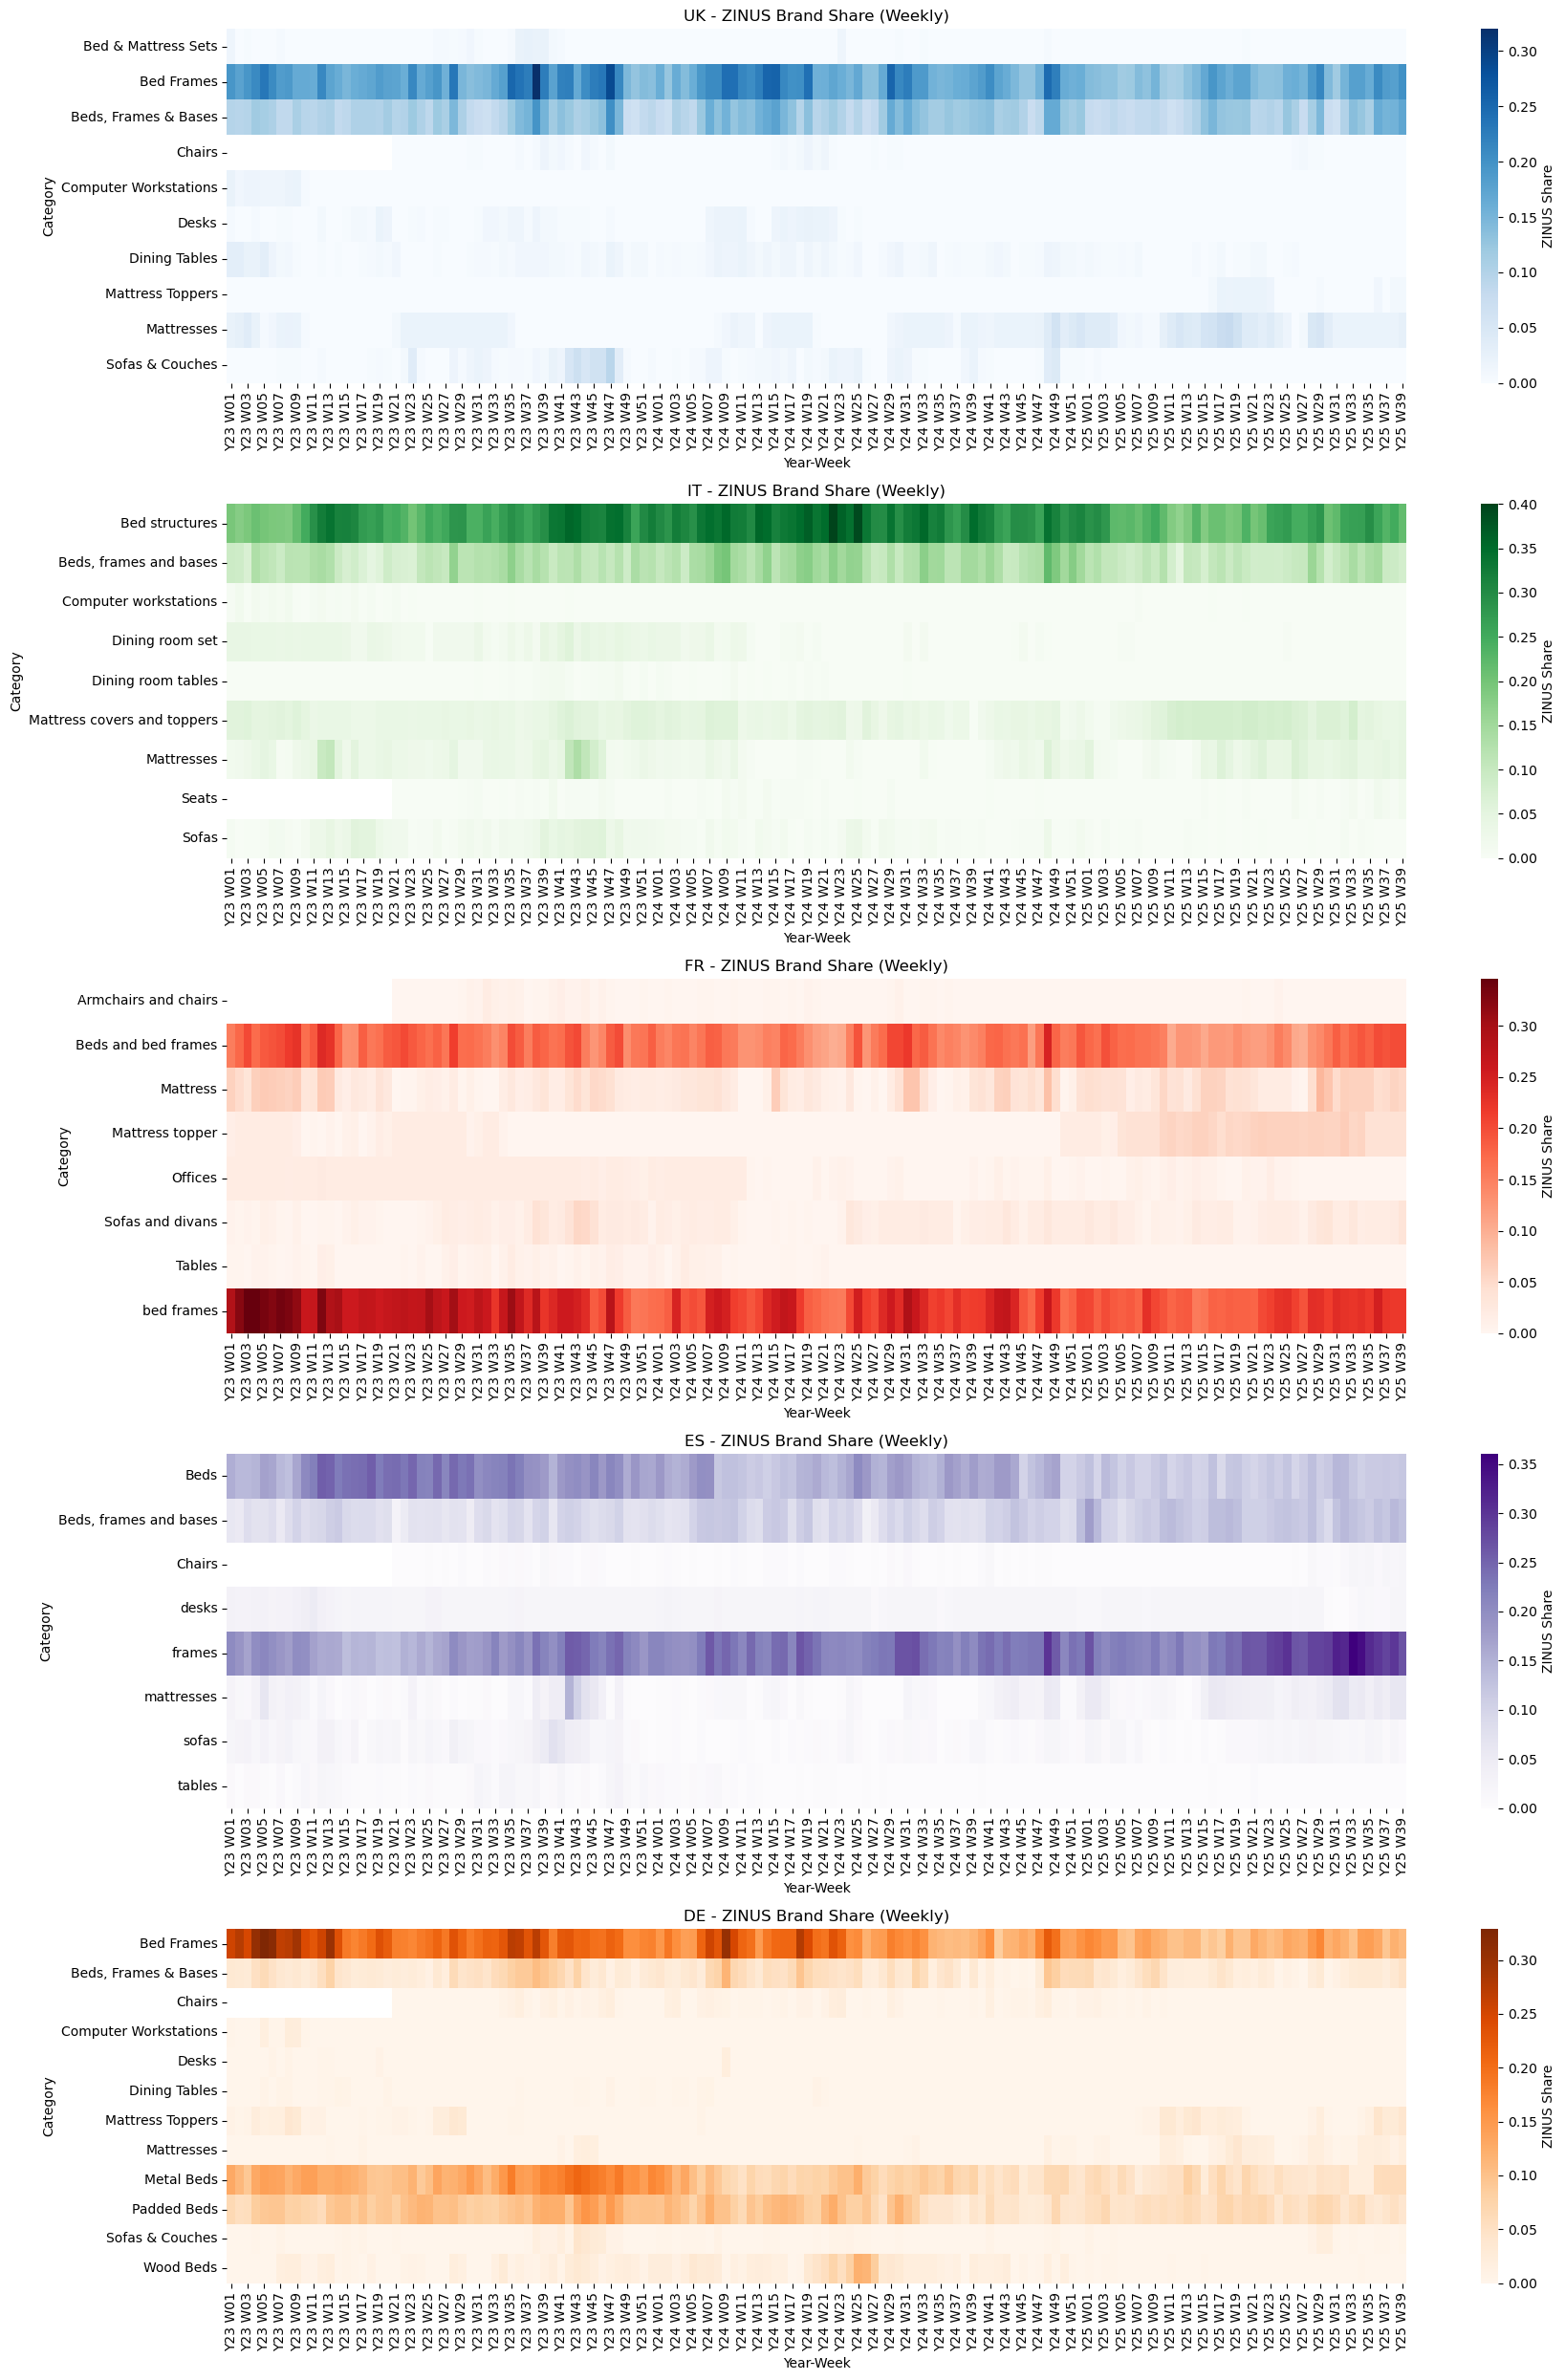

In [17]:

# ✅ 대상 국가
target_countries = ["UK", "IT", "FR", "ES", "DE"]

# ✅ 국가별로 다른 컬러맵 지정
cmaps = {
    "UK": "Blues",
    "IT": "Greens",
    "FR": "Reds",
    "ES": "Purples",
    "DE": "Oranges"
}

# ✅ subplot 생성
fig, axes = plt.subplots(len(target_countries), 1, figsize=(18, 5*len(target_countries)))

for ax, country in zip(axes, target_countries):
    data_cty = filtered[filtered['country'] == country]
    pivot_cty = data_cty.pivot_table(
        index='bsr_ctgry',
        columns='yr_week',
        values='zinus_share',
        aggfunc='mean'
    )

    sns.heatmap(
        pivot_cty,
        cmap=cmaps[country],
        annot=False,
        cbar_kws={'label': 'ZINUS Share'},
        ax=ax
    )
    ax.set_title(f"{country} - ZINUS Brand Share (Weekly)", fontsize=12)
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

## 3. Top 브랜드 점유울 추이

In [12]:
df1 = df.copy()
df1['brand'] = df1['brand'].astype(str).str.upper()

# === 1) 대상 국가/카테고리 필터 ===
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"],
}
mask_list = [
    (df1['country'] == c) & (df1['bsr_ctgry'].isin(cats))
    for c, cats in allowed_pairs.items()
]

df2 = df1[np.logical_or.reduce(mask_list)].copy()
# NO BRAND INFO --> OTHERS
df2['brand'] = df2['brand'].replace('NO BRAND INFO', 'OTHERS')

print(df2)

        country               bsr_ctgry        asin  rank    bsr_date  \
0            ES              mattresses  B0CMQYC3TR    41  2024-11-08   
1            ES              mattresses  B0CLLTX4DL    48  2024-08-02   
3            DE              Mattresses  B01N5QV0CA     5  2024-09-12   
4            DE              Mattresses  B01NAQ1DL1    22  2023-02-15   
5            ES              mattresses  B07CWV5QTV    41  2025-04-15   
...         ...                     ...         ...   ...         ...   
1577584      ES  Beds, frames and bases  B0CB6W36CN    28  2024-09-27   
1577585      ES  Beds, frames and bases  B00T9Y8TQA    45  2023-02-02   
1577586      ES  Beds, frames and bases  B0CQKV3BPX    18  2025-04-04   
1577587      ES  Beds, frames and bases  B07MTB8TRX    48  2025-03-16   
1577588      ES  Beds, frames and bases  B07YLHWVWD    32  2025-05-03   

                     brand                           brand_raw  \
0          DUÉRMETE ONLINE                     DUÉRMETE O

In [14]:
# === 2) 주차별 전체/브랜드별 카운트 ===
tot = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_week'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_week', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_wk = by_brand.merge(tot, on=['country','bsr_ctgry','yr_week'], how='left')
df_wk['brand_share_weekly'] = df_wk['brand_count'] / df_wk['total_count']

print(df_wk)

      country             bsr_ctgry  yr_week           brand  brand_count  \
0          DE  Beds, Frames & Bases  Y23 W01       AGUA NOVA           14   
1          DE  Beds, Frames & Bases  Y23 W01      BETTEN-ABC           36   
2          DE  Beds, Frames & Bases  Y23 W01           COEMO            8   
3          DE  Beds, Frames & Bases  Y23 W01        DREAMZIE            7   
4          DE  Beds, Frames & Bases  Y23 W01          JUSKYS           14   
...       ...                   ...      ...             ...          ...   
15435      UK            Mattresses  Y25 W40          OTHERS           85   
15436      UK            Mattresses  Y25 W40  STARLIGHT BEDS            6   
15437      UK            Mattresses  Y25 W40          TEQSLI           14   
15438      UK            Mattresses  Y25 W40       VESGANTTI           12   
15439      UK            Mattresses  Y25 W40           ZINUS            6   

       total_count  brand_share_weekly  
0              350            0.04

In [28]:
# === 4) country × bsr_ctgry × brand 단위로 집계
# (가중 평균 = sum(brand_count) / sum(total_count))
agg = (
    df_wk.groupby(['country','bsr_ctgry','brand'], as_index=False)
      .agg(
          brand_count_sum=('brand_count','sum'),
          total_count_sum=('total_count','sum')
      )
)
agg['brand_share'] = agg['brand_count_sum'] / agg['total_count_sum']

# 최종 프레임: country, bsr_ctgry, brand별 BSR 점유율
brand_share_ccb = agg[['country','bsr_ctgry','brand','brand_share']].copy()

# 필요 시 정렬 예시 (점유율 내림차순)
brand_share_ccb = brand_share_ccb.sort_values(
    ['country','bsr_ctgry','brand_share'],
    ascending=[True, True, False]
).reset_index(drop=True)

print(brand_share_ccb.head(20))

   country             bsr_ctgry              brand  brand_share
0       DE  Beds, Frames & Bases             OTHERS     0.503376
1       DE  Beds, Frames & Bases          YAHEETECH     0.098199
2       DE  Beds, Frames & Bases  SCHLUMMERPARADIES     0.087603
3       DE  Beds, Frames & Bases         BETTEN-ABC     0.067109
4       DE  Beds, Frames & Bases             JUSKYS     0.044724
5       DE  Beds, Frames & Bases              ZINUS     0.040312
6       DE  Beds, Frames & Bases              COEMO     0.039904
7       DE  Beds, Frames & Bases             MURALO     0.034246
8       DE  Beds, Frames & Bases          AGUA NOVA     0.032205
9       DE  Beds, Frames & Bases           DREAMZIE     0.032007
10      DE  Beds, Frames & Bases        LILENO HOME     0.029912
11      DE            Mattresses             OTHERS     0.427614
12      DE            Mattresses         TRAUMNACHT     0.133150
13      DE            Mattresses            MOLBLLY     0.111588
14      DE            Mat

In [34]:
brand_share_ccb.to_csv('brand_share_by_country_ctgry.csv')

In [30]:
df_bs = brand_share_ccb.query("country == 'UK' and bsr_ctgry == 'Mattresses'")
df_bs.sort_values('brand_share', ascending=False)

,country,bsr_ctgry,brand,brand_share
101,UK,Mattresses,OTHERS,0.427849
102,UK,Mattresses,VESGANTTI,0.103289
103,UK,Mattresses,MOLBLLY,0.084494
104,UK,Mattresses,TEQSLI,0.076856
105,UK,Mattresses,STARLIGHT BEDS,0.072111
106,UK,Mattresses,INOFIA,0.055009
107,UK,Mattresses,BEDZONLINE,0.052060
108,UK,Mattresses,EXTREME COMFORT LTD,0.051266
109,UK,Mattresses,DOSLEEPS,0.034449
110,UK,Mattresses,GOOD NITE,0.034394


### pie 차트 그리기

In [ ]:
# country, bsr_ctgry 별로 파이 차트 생성
countries = brand_share_ccb['country'].unique()
categories = brand_share_ccb['bsr_ctgry'].unique()

nrows = len(countries)
ncols = len(categories)

#fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))

for country in brand_share_ccb['country'].unique():
    for cat in brand_share_ccb['bsr_ctgry'].unique():
        subset = brand_share_ccb[(brand_share_ccb['country'] == country) & (brand_share_ccb['bsr_ctgry'] == cat)]
        if not subset.empty:
            plt.figure(figsize=(6,6))
            plt.pie(subset['brand_share'], labels=subset['brand'], autopct='%1.1f%%', startangle=140)
            plt.title(f"{country} - {cat}")
            plt.show()

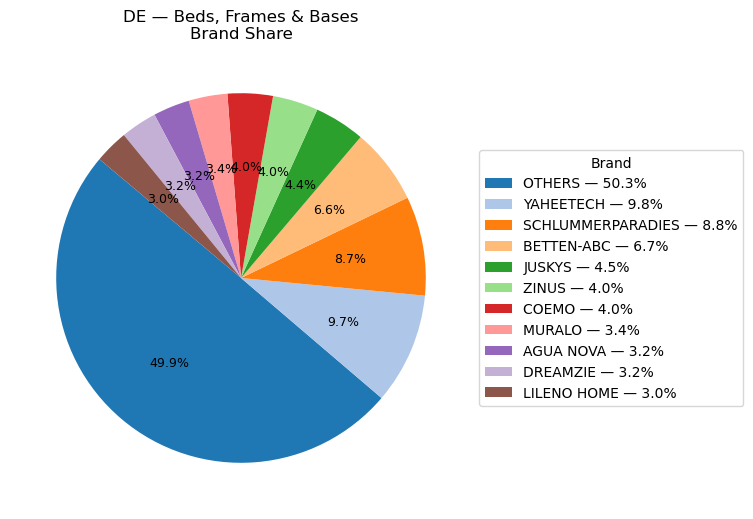

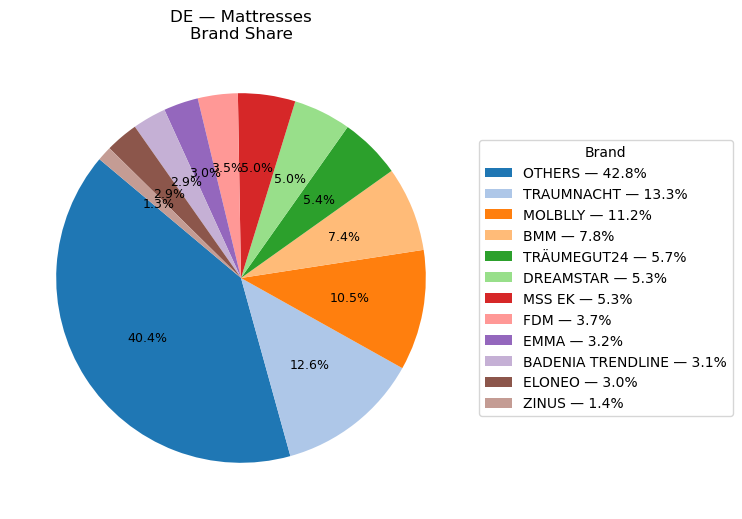

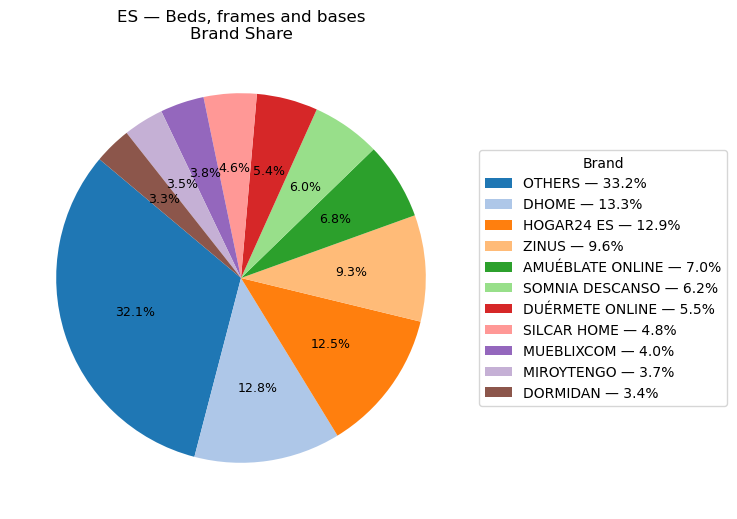

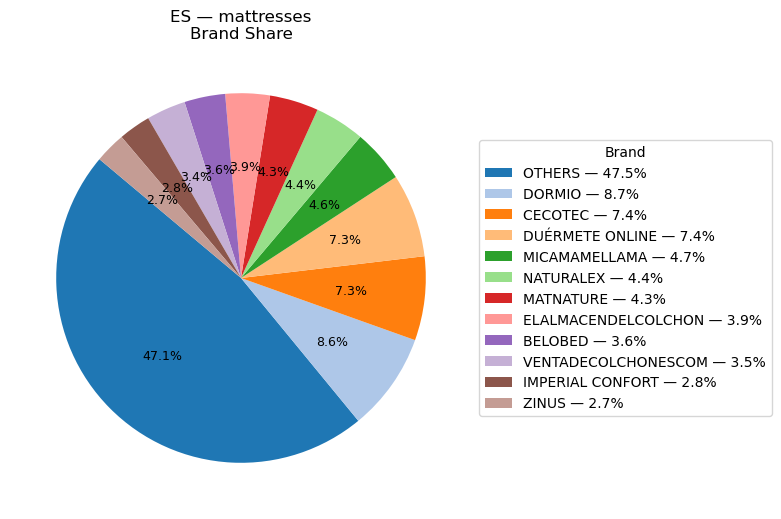

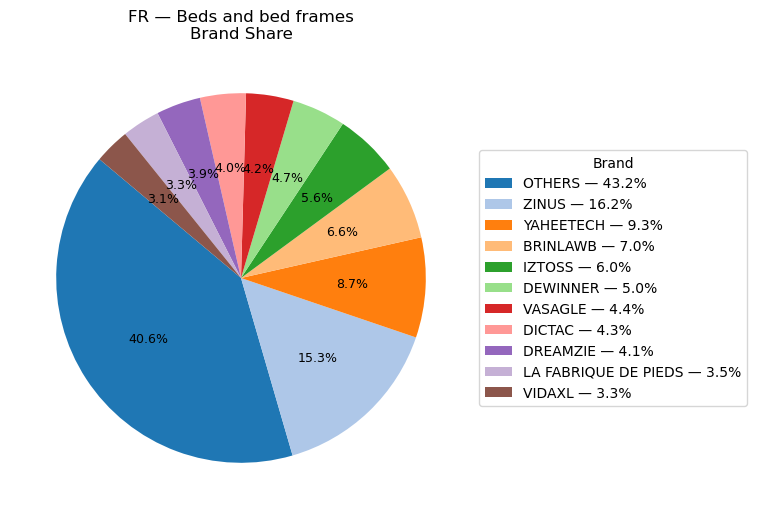

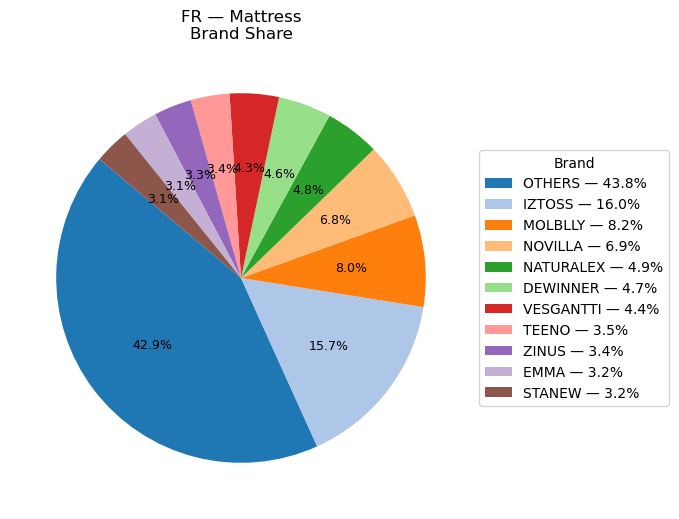

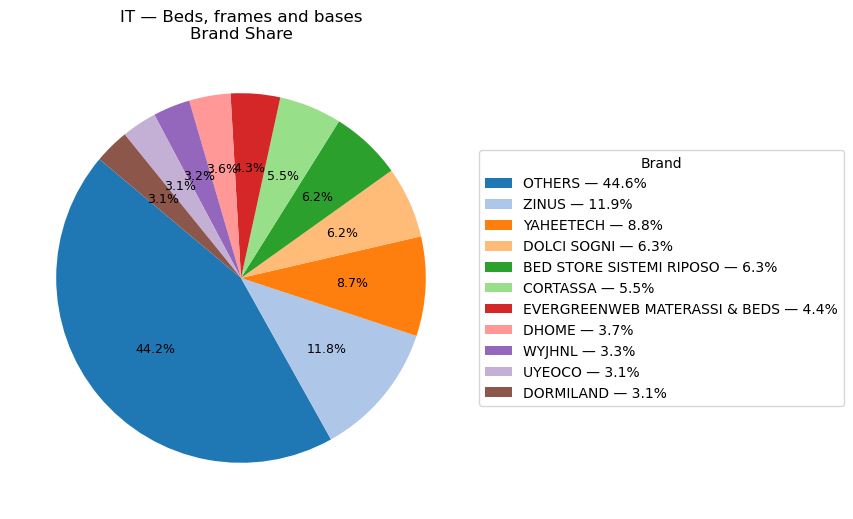

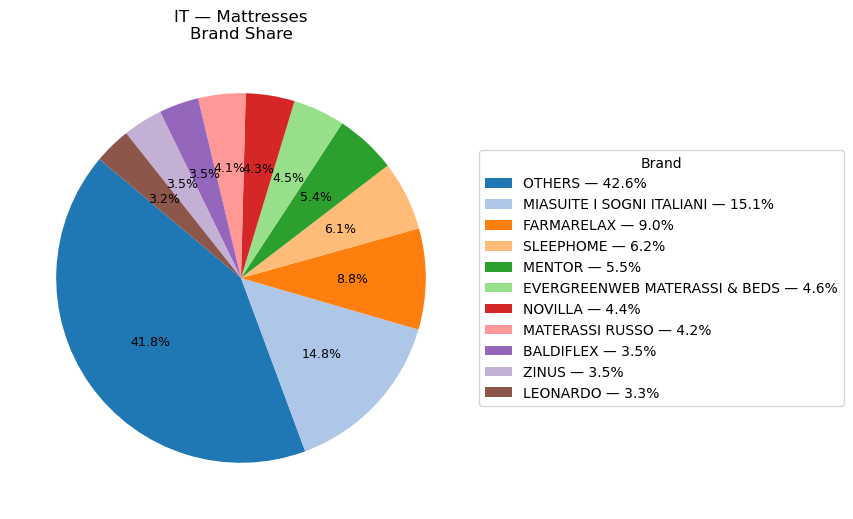

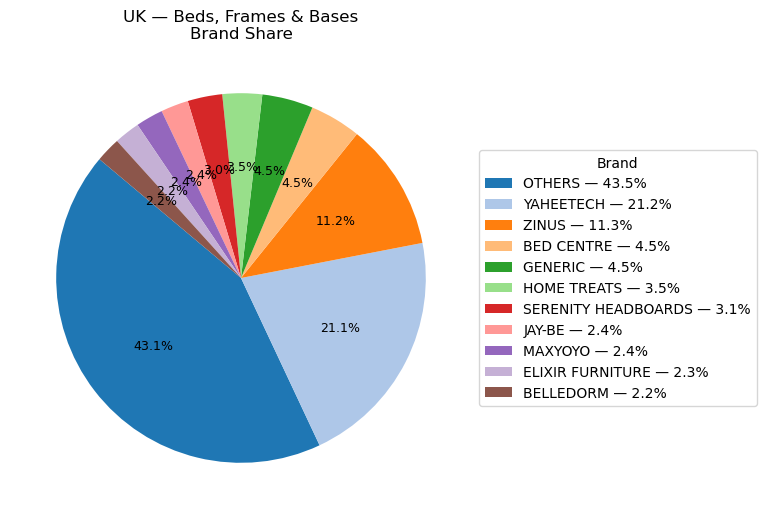

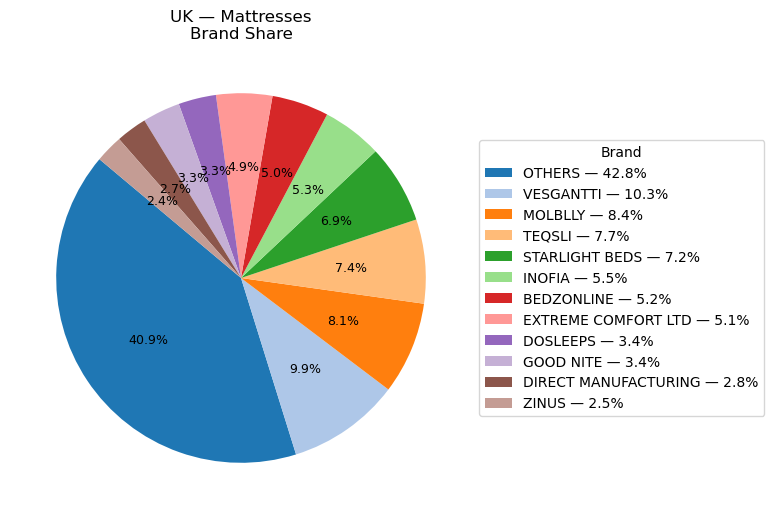

In [32]:

def plot_brand_share_pie(df, country, category):
    # 조건 필터
    subset = df[(df['country'] == country) & (df['bsr_ctgry'] == category)]
    if subset.empty:
        return

    # 퍼센트 변환
    shares = subset['brand_share'] * 100
    brands = subset['brand']

    # 색상 팔레트
    colors = plt.cm.tab20.colors[:len(brands)]

    # 파이차트
    fig, ax = plt.subplots(figsize=(7, 6))
    wedges, texts, autotexts = ax.pie(
        shares,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        textprops={'fontsize': 9}
    )

    # 범례 (브랜드 — 퍼센트)
    legend_labels = [f"{b} — {s:.1f}%" for b, s in zip(brands, shares)]
    ax.legend(wedges, legend_labels, title="Brand", loc="center left", bbox_to_anchor=(1, 0.5))

    # 타이틀
    ax.set_title(f"{country} — {category}\nBrand Share", fontsize=12)

    plt.show()


# ---------- 모든 country × category 실행 ----------
for country in brand_share_ccb['country'].unique():
    for category in brand_share_ccb.loc[brand_share_ccb['country'] == country, 'bsr_ctgry'].unique():
        plot_brand_share_pie(brand_share_ccb, country, category)

### Top 10 그래프 

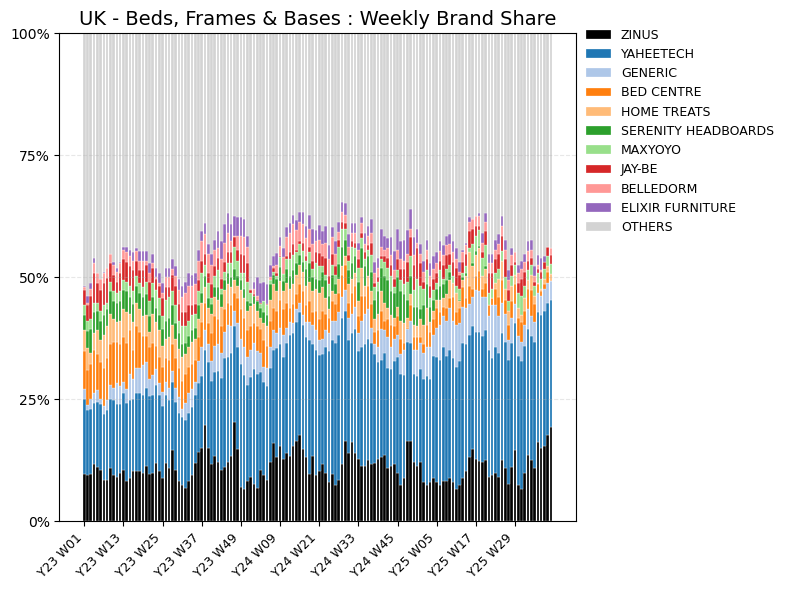

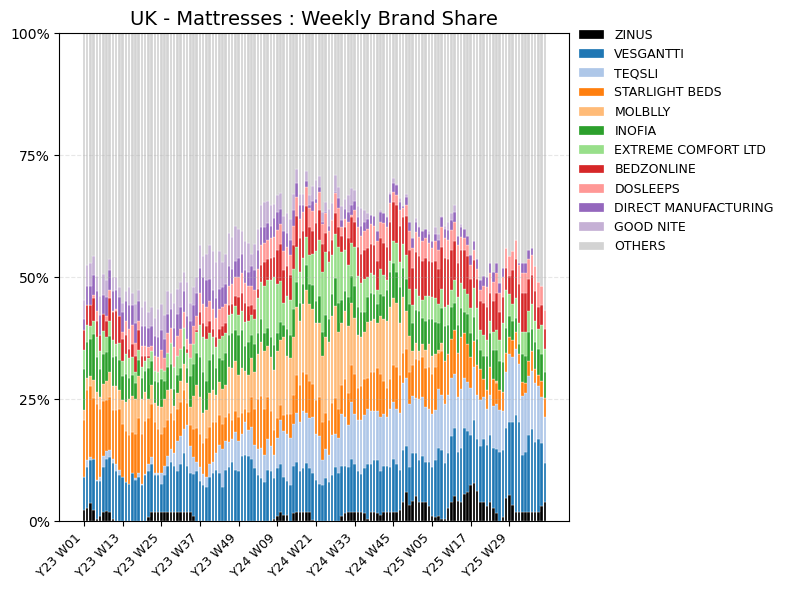

In [27]:
# ---------- 유틸 ----------
def parse_yrweek(s: str):
    """'Y23 W01' → (2023, 1) 숫자 튜플 (정렬용 키)"""
    m = re.search(r'Y(\d{2})\s*W0?(\d{1,2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (9999, 99)  # 매칭 실패 시 맨 뒤로

def make_colors(n: int):
    """브랜드가 많을 경우 대비해서 색상 팔레트 확장"""
    cols = []
    for cm in (plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c):
        cols.extend([cm(i) for i in range(cm.N)])  # 총 60색
    if n > len(cols):
        extra = n - len(cols)
        cols.extend([plt.cm.hsv(i / max(1, extra)) for i in range(extra)])
    return cols[:n]

# ---------- 파라미터 ----------
MAX_XTICKS = 12   # X축 라벨 최대 개수
FIGSIZE = (8, 6) # 그림 크기

# ---------- 데이터 준비 ----------
df_plot = df_wk[df_wk['country'] == 'UK'].copy()

# 카테고리별 그래프
for cat, g in df_plot.groupby('bsr_ctgry', sort=True):
    # 주차 정렬
    weeks = sorted(g['yr_week'].unique(), key=parse_yrweek)
    if len(weeks) == 0:
        continue

    # pivot: index=yr_week, columns=brand, values=brand_share_weekly
    pvt = (
        g.groupby(['yr_week','brand'])['brand_share_weekly']
         .sum()
         .unstack(fill_value=0.0)
         .reindex(weeks)
         .fillna(0.0)
    )

    # 컬럼 순서: ZINUS 맨 앞, OTHERS 맨 뒤, 나머지는 합계 내림차순
    cols = list(pvt.columns)
    has_zinus = 'ZINUS' in cols
    has_others = 'OTHERS' in cols
    rest = [c for c in cols if c not in ('ZINUS','OTHERS')]
    rest_sorted = pvt[rest].sum(axis=0).sort_values(ascending=False).index.tolist()
    ordered_cols = (['ZINUS'] if has_zinus else []) + rest_sorted + (['OTHERS'] if has_others else [])
    pvt = pvt.reindex(columns=ordered_cols)

    # 색상 매핑
    cmap = {}
    if has_zinus: cmap['ZINUS'] = 'black'
    if has_others: cmap['OTHERS'] = 'lightgray'
    rest_for_colors = [c for c in ordered_cols if c not in ('ZINUS','OTHERS')]
    color_list = make_colors(len(rest_for_colors))
    for j, br in enumerate(rest_for_colors):
        cmap[br] = color_list[j]

    # --- Plot ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    x = np.arange(len(weeks))
    bottom = np.zeros(len(weeks), dtype=float)

    for col in pvt.columns:
        ax.bar(
            x, pvt[col].values,
            bottom=bottom,
            label=col,
            color=cmap.get(col, None),
            edgecolor='white', linewidth=0.2
        )
        bottom += pvt[col].values

    # Y축 (비율, 0~100%)
    ax.set_ylim(0, 1.0)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0%','25%','50%','75%','100%'])

    ax.set_title(f"UK - {cat} : Weekly Brand Share", fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # X축: 주차 샘플링
    n = len(weeks)
    step = max(1, int(np.ceil(n / MAX_XTICKS)))
    tick_idx = np.arange(0, n, step)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([weeks[i] for i in tick_idx], rotation=45, ha='right', fontsize=9)

    # 범례: 바깥쪽
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))  # 중복 제거
    ax.legend(
        by_label.values(), by_label.keys(),
        loc='upper left', bbox_to_anchor=(1.01, 1.02),
        borderaxespad=0., fontsize=9, frameon=False,
        ncol=1 if len(by_label) < 20 else 2
    )

    plt.tight_layout()
    plt.show()

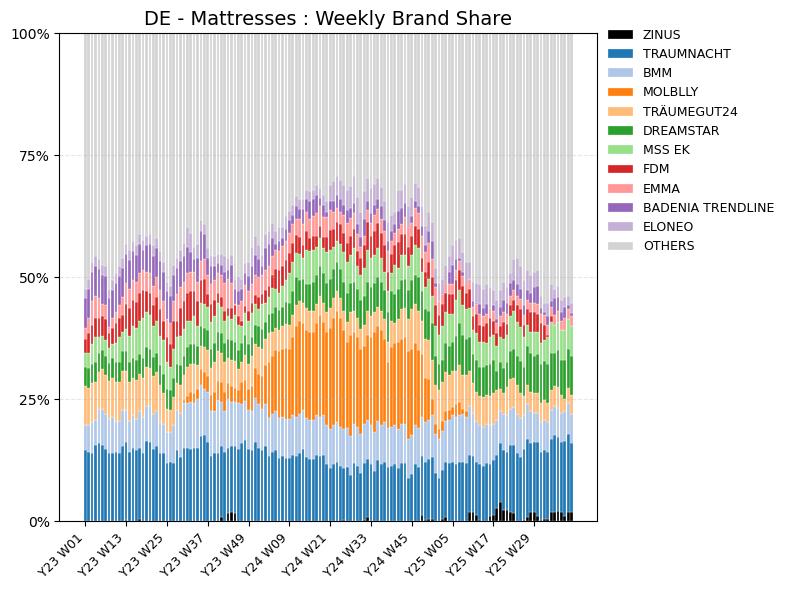

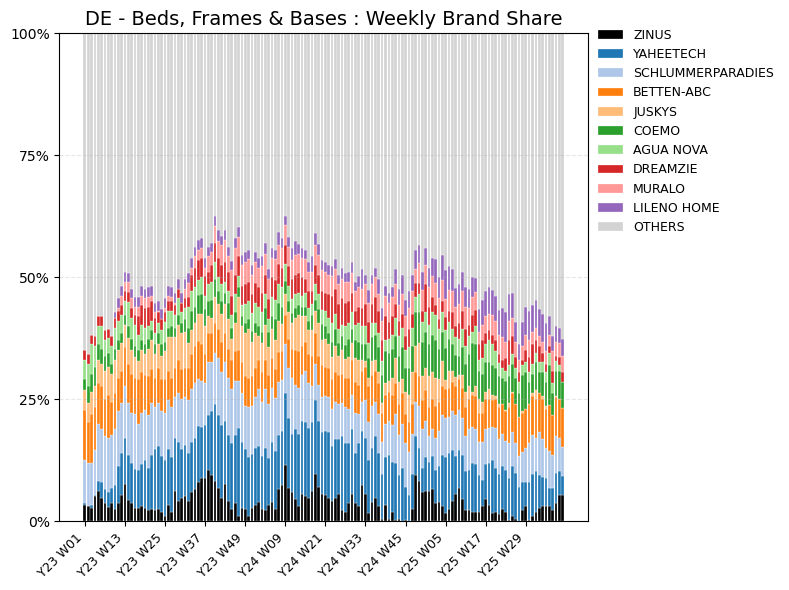

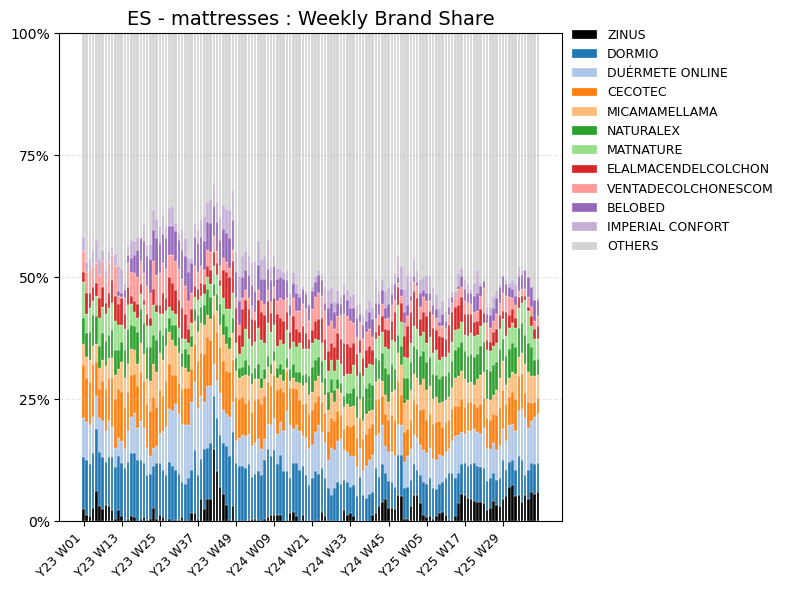

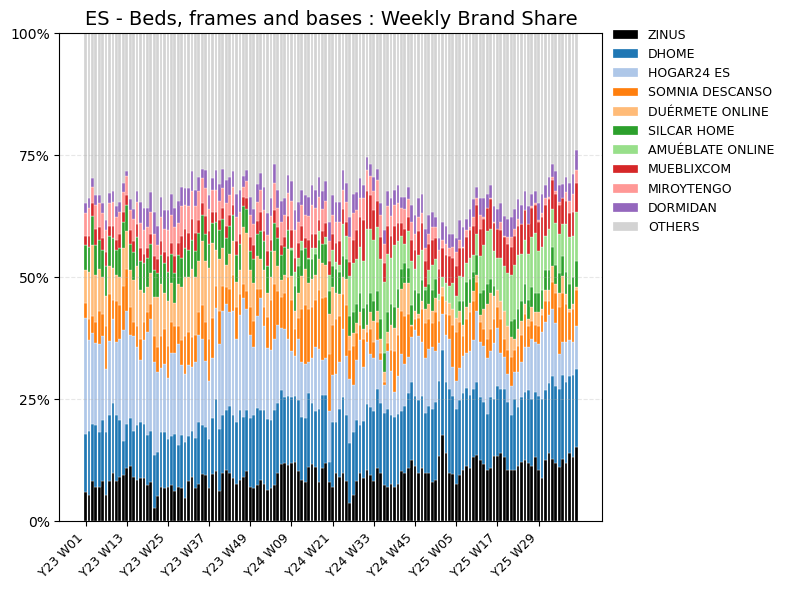

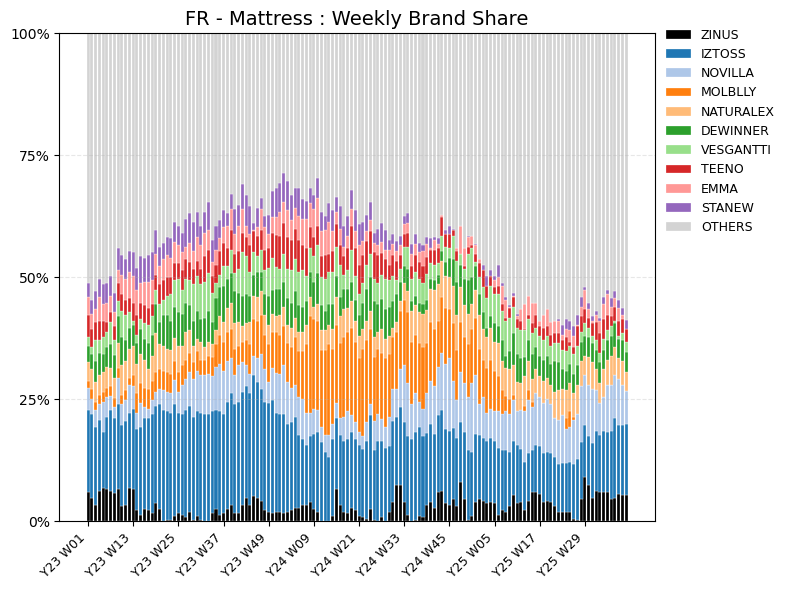

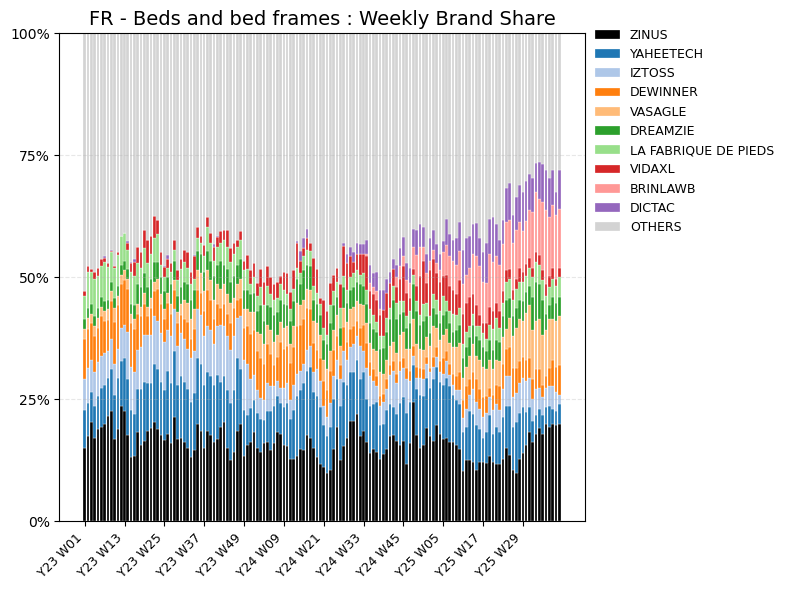

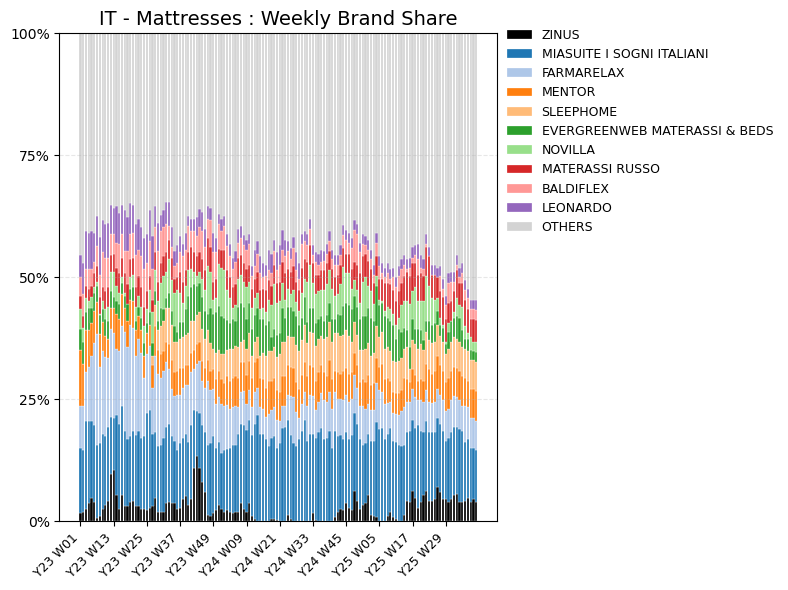

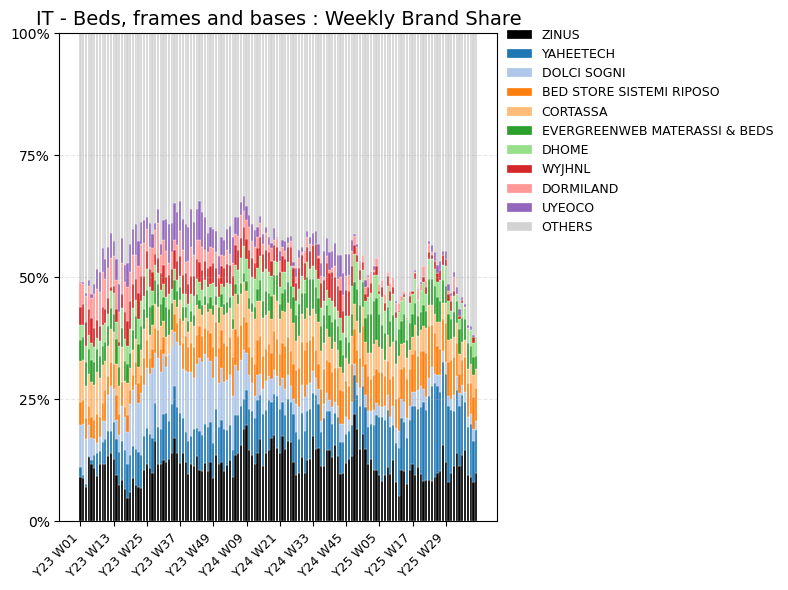

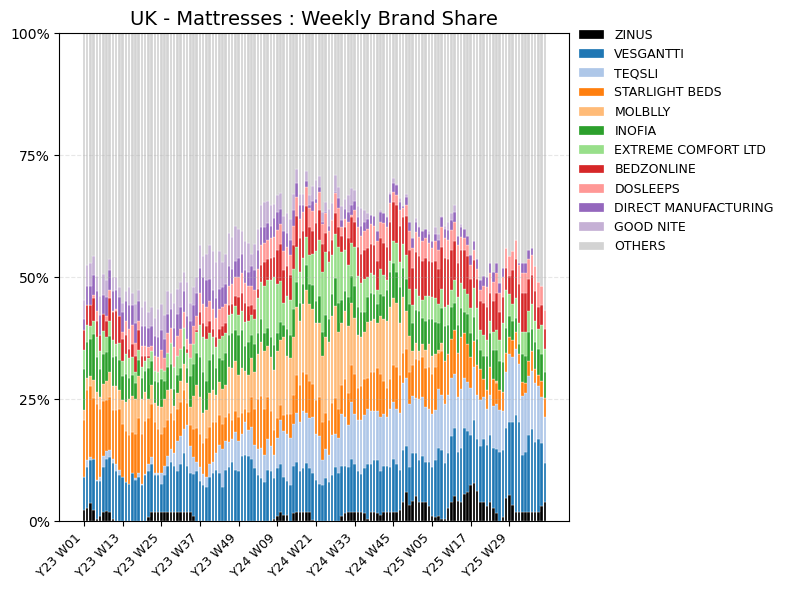

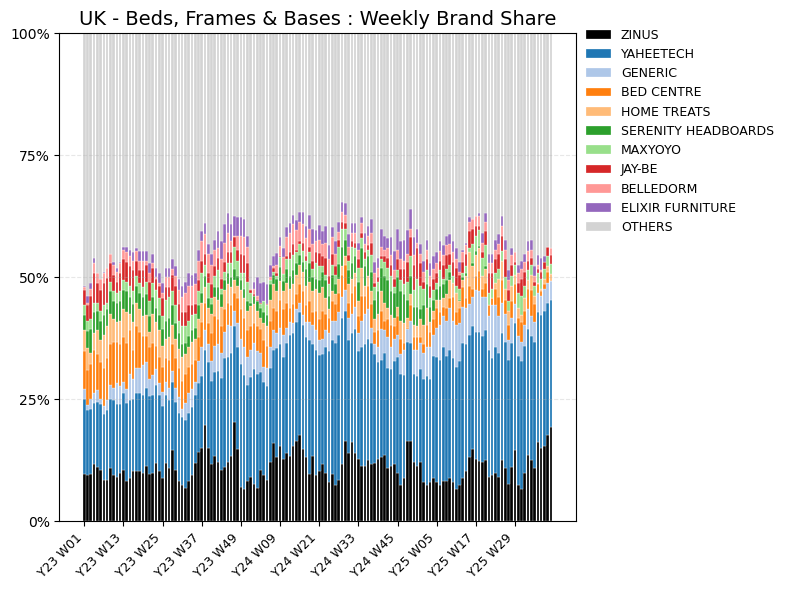

In [44]:
def parse_yrweek(s: str):
    """'Y23 W01' → (2023, 1) 숫자 튜플 (정렬용 키)"""
    m = re.search(r'Y(\d{2})\s*W0?(\d{1,2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (9999, 99)  # 매칭 실패 시 맨 뒤로

def make_colors(n: int):
    """브랜드가 많을 경우 대비해서 색상 팔레트 확장"""
    cols = []
    for cm in (plt.cm.tab20, plt.cm.tab20b, plt.cm.tab20c):
        cols.extend([cm(i) for i in range(cm.N)])  # 총 60색
    if n > len(cols):
        extra = n - len(cols)
        cols.extend([plt.cm.hsv(i / max(1, extra)) for i in range(extra)])
    return cols[:n]

# ---------- 파라미터 ----------
MAX_XTICKS = 12   # X축 라벨 최대 개수
FIGSIZE = (8, 6)  # 그림 크기

# ---------- 모든 국가 대상으로 개별 그래프 ----------
for country, df_c in df_wk.groupby('country', sort=True):
    if df_c.empty:
        continue

    # 카테고리 정렬: 'mattress' 포함 먼저, 그 다음 알파벳순
    cats = sorted(
        df_c['bsr_ctgry'].dropna().unique(),
        key=lambda c: (0 if ('mattress' in str(c).lower()) else 1, str(c).lower())
    )

    for cat in cats:
        g = df_c[df_c['bsr_ctgry'] == cat].copy()
        if g.empty:
            continue

        # --- 주차 정렬 ---
        weeks = sorted(g['yr_week'].dropna().unique(), key=parse_yrweek)
        if not weeks:
            continue

        # --- pivot: index=yr_week, columns=brand, values=brand_share_weekly ---
        pvt = (
            g.groupby(['yr_week', 'brand'])['brand_share_weekly']
             .sum()
             .unstack(fill_value=0.0)
             .reindex(weeks)
             .fillna(0.0)
        )

        # --- 컬럼 순서: ZINUS 맨 앞, OTHERS 맨 뒤, 나머지는 합계 내림차순 ---
        cols = list(pvt.columns)
        has_zinus = 'ZINUS' in cols
        has_others = 'OTHERS' in cols
        rest = [c for c in cols if c not in ('ZINUS', 'OTHERS')]
        rest_sorted = pvt[rest].sum(axis=0).sort_values(ascending=False).index.tolist()
        ordered_cols = (['ZINUS'] if has_zinus else []) + rest_sorted + (['OTHERS'] if has_others else [])
        pvt = pvt.reindex(columns=ordered_cols)

        # --- 색상 매핑 ---
        cmap = {}
        if has_zinus: cmap['ZINUS'] = 'black'
        if has_others: cmap['OTHERS'] = 'lightgray'
        rest_for_colors = [c for c in ordered_cols if c not in ('ZINUS', 'OTHERS')]
        color_list = make_colors(len(rest_for_colors))
        for j, br in enumerate(rest_for_colors):
            cmap[br] = color_list[j]

        # --- 개별 Figure로 그리기 ---
        fig, ax = plt.subplots(figsize=FIGSIZE)
        x = np.arange(len(weeks))
        bottom = np.zeros(len(weeks), dtype=float)

        for col in pvt.columns:
            ax.bar(
                x, pvt[col].values,
                bottom=bottom,
                label=col,
                color=cmap.get(col, None),
                edgecolor='white', linewidth=0.2
            )
            bottom += pvt[col].values

        # Y축 (비율, 0~100%)
        ax.set_ylim(0, 1.0)
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])

        ax.set_title(f"{country} - {cat} : Weekly Brand Share", fontsize=14)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # X축: 주차 라벨 샘플링
        n = len(weeks)
        step = max(1, int(np.ceil(n / MAX_XTICKS)))
        tick_idx = np.arange(0, n, step)
        ax.set_xticks(tick_idx)
        ax.set_xticklabels([weeks[i] for i in tick_idx], rotation=45, ha='right', fontsize=9)

        # 범례: 바깥쪽
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))  # 중복 제거
        ax.legend(
            by_label.values(), by_label.keys(),
            loc='upper left', bbox_to_anchor=(1.01, 1.02),
            borderaxespad=0., fontsize=9, frameon=False,
            ncol=1 if len(by_label) < 20 else 2
        )

        plt.tight_layout()
        plt.show()

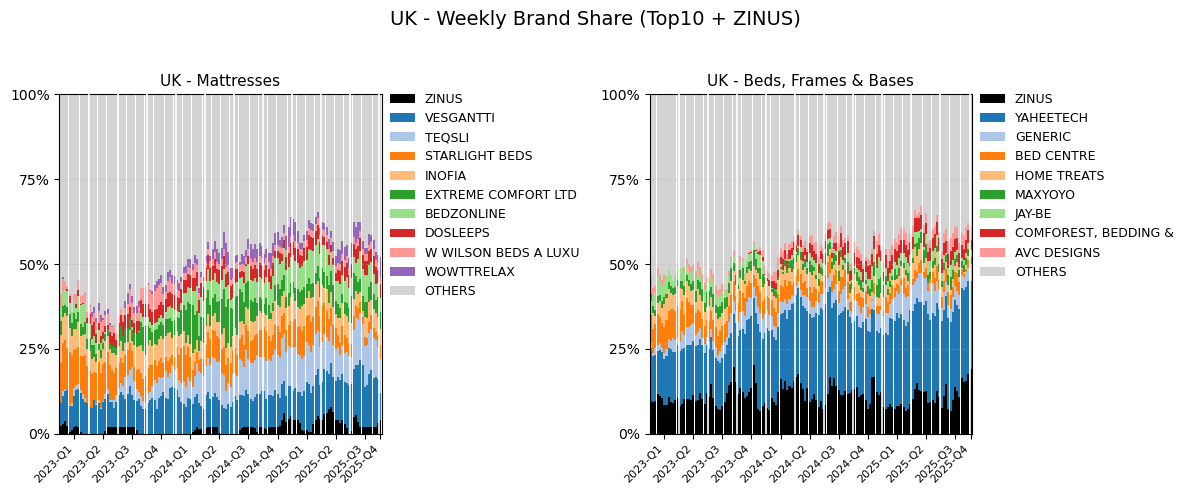

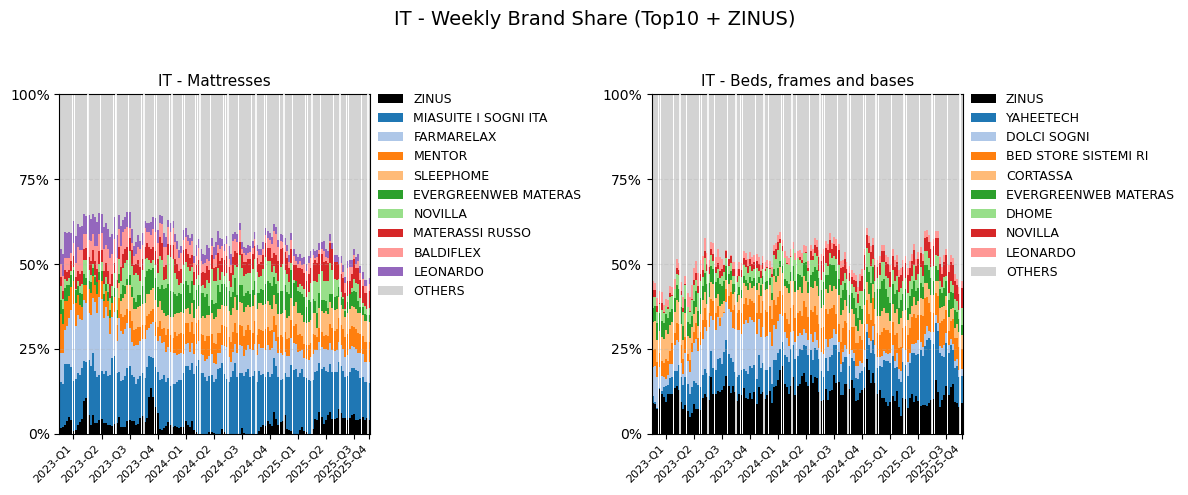

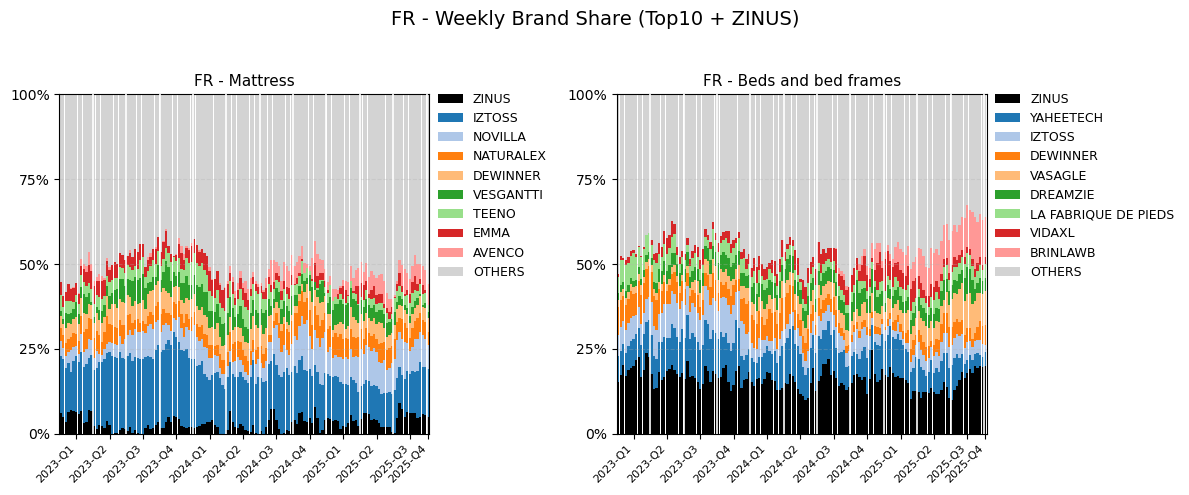

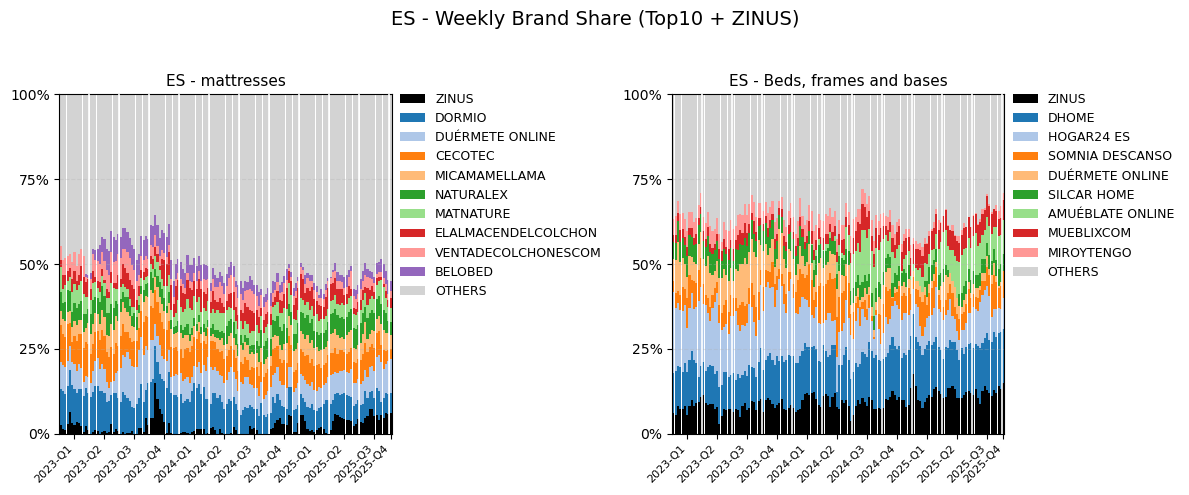

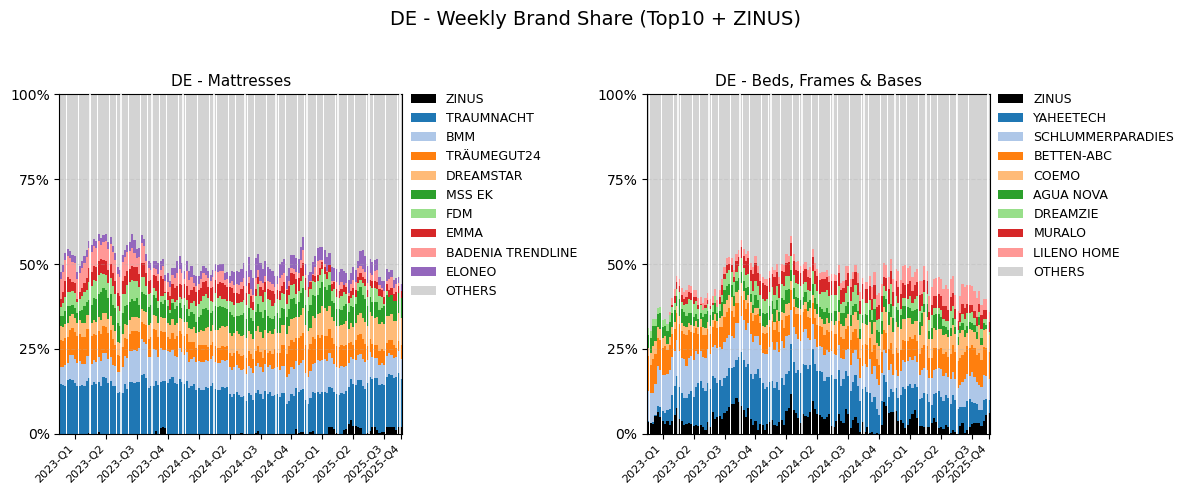

In [71]:
# ---- Helper: 분기 라벨 & 경계 ----
def quarter_label_from_week(wlabel):
    y, wk = parse_yrweek(wlabel)
    q = (wk - 1)//13 + 1
    return f"{y}-Q{q}"

def quarter_bounds_from_weeks(weeks):
    qlabs = [quarter_label_from_week(w) for w in weeks]
    bounds, s = [], 0
    for i in range(1, len(qlabs)):
        if qlabs[i] != qlabs[i-1]:
            bounds.append((s, i-1, qlabs[i-1]))
            s = i
    if qlabs:
        bounds.append((s, len(qlabs)-1, qlabs[-1]))
    return bounds


# ---- 국가별 Figure ----
countries = ['UK','IT','FR','ES','DE']
for country in countries:
    sub_country = comp[comp['country'] == country].copy()
    if sub_country.empty:
        continue

    # ✅ 카테고리: 'Mattress' 포함 우선 + 나머지는 알파벳순
    cats = list(sub_country['bsr_ctgry'].unique())
    cats = sorted(cats, key=lambda c: (0 if 'mattress' in c.lower() else 1, c.lower()))

    ncols = 2
    nrows = math.ceil(len(cats)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{country} - Weekly Brand Share (Top10 + ZINUS)", fontsize=14, y=0.98)

    for i, cat in enumerate(cats):
        ax  = axes[i//ncols, i%ncols]
        sub = sub_country[sub_country['bsr_ctgry'] == cat].copy()
        if sub.empty:
            ax.axis('off'); continue

        # --- 주차 정렬 & pivot ---
        weeks = sorted(sub['yr_week'].unique(), key=parse_yrweek)
        pivot = (sub.pivot_table(index='yr_week', columns='brand_compact',
                                 values='brand_share', aggfunc='sum')
                   .reindex(index=weeks).fillna(0.0))

        for req in ('ZINUS','OTHERS'):
            if req not in pivot.columns:
                pivot[req] = 0.0

        # --- 스택 순서 ---
        rest = [c for c in pivot.columns if c not in ('ZINUS','OTHERS')]
        rest_sorted = pivot[rest].sum(0).sort_values(ascending=False).index.tolist()
        pivot = pivot[['ZINUS', *rest_sorted, 'OTHERS']]

        # --- 100% 정규화 ---
        pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0)

        # --- 색상 ---
        base_colors = plt.cm.tab20.colors
        color_map = {'ZINUS':'black','OTHERS':'lightgray'}
        for j, br in enumerate(rest_sorted):
            color_map[br] = base_colors[j % len(base_colors)]

        # --- 막대 ---
        x = np.arange(len(pivot))
        bottom = np.zeros(len(pivot))
        for col in pivot.columns:
            ax.bar(x, pivot[col].values, bottom=bottom, width=0.9,
                   label=(col if len(col) <= 20 else col[:20]),
                   color=color_map[col])
            bottom += pivot[col].values

        # --- Y축 ---
        ax.set_ylim(0, 1)
        ax.set_yticks([0,.25,.5,.75,1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xlim(-0.5, len(x)-0.5)

        # ✅ 타이틀: 국가 + 카테고리
        ax.set_title(f"{country} - {cat}", fontsize=11)

        # --- X축: 분기 라벨 & 구분선 ---
        qbounds = quarter_bounds_from_weeks(weeks)
        ax.set_xticks([(s+e)/2 for s,e,_ in qbounds])
        ax.set_xticklabels([lbl for _,_,lbl in qbounds], rotation=45, ha='right', fontsize=8)
        for s, e, _ in qbounds[:-1]:
            ax.axvline(e+0.5, color='white', linewidth=1.2, zorder=3)

        # --- 범례 ---
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02),
                  borderaxespad=0., fontsize=9, frameon=False)

    # 빈축 제거
    for j in range(i+1, nrows*ncols):
        axes[j//ncols, j%ncols].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


## 9. 기타

### - 월별 BSR Share 

In [63]:
df1 = df.copy()
df1['brand'] = df1['brand'].astype(str).str.upper()

# === 1) 대상 국가/카테고리 필터 ===
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"],
}
mask_list = [
    (df1['country'] == c) & (df1['bsr_ctgry'].isin(cats))
    for c, cats in allowed_pairs.items()
]

df2 = df1[np.logical_or.reduce(mask_list)].copy()
# NO BRAND INFO --> OTHERS
df2['brand'] = df2['brand'].replace('NO BRAND INFO', 'OTHERS')

print(df2)

        country               bsr_ctgry        asin  rank    bsr_date  \
0            ES              mattresses  B0CMQYC3TR    41  2024-11-08   
1            ES              mattresses  B0CLLTX4DL    48  2024-08-02   
3            DE              Mattresses  B01N5QV0CA     5  2024-09-12   
4            DE              Mattresses  B01NAQ1DL1    22  2023-02-15   
5            ES              mattresses  B07CWV5QTV    41  2025-04-15   
...         ...                     ...         ...   ...         ...   
1577584      ES  Beds, frames and bases  B0CB6W36CN    28  2024-09-27   
1577585      ES  Beds, frames and bases  B00T9Y8TQA    45  2023-02-02   
1577586      ES  Beds, frames and bases  B0CQKV3BPX    18  2025-04-04   
1577587      ES  Beds, frames and bases  B07MTB8TRX    48  2025-03-16   
1577588      ES  Beds, frames and bases  B07YLHWVWD    32  2025-05-03   

                     brand                           brand_raw  \
0          DUÉRMETE ONLINE                     DUÉRMETE O

In [92]:
# === 2) 주차별 전체/브랜드별 카운트 ===
tot = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df2.groupby(['country', 'bsr_ctgry', 'yr_month', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_mo = by_brand.merge(tot, on=['country','bsr_ctgry','yr_month'], how='left')
df_mo['brand_share_monthly'] = df_mo['brand_count'] / df_mo['total_count']

print(df_mo)

     country             bsr_ctgry yr_month           brand  brand_count  \
0         DE  Beds, Frames & Bases    23-01       AGUA NOVA           66   
1         DE  Beds, Frames & Bases    23-01      BETTEN-ABC          131   
2         DE  Beds, Frames & Bases    23-01           COEMO           47   
3         DE  Beds, Frames & Bases    23-01        DREAMZIE           28   
4         DE  Beds, Frames & Bases    23-01          JUSKYS           59   
...      ...                   ...      ...             ...          ...   
3699      UK            Mattresses    25-10          OTHERS           85   
3700      UK            Mattresses    25-10  STARLIGHT BEDS            6   
3701      UK            Mattresses    25-10          TEQSLI           14   
3702      UK            Mattresses    25-10       VESGANTTI           12   
3703      UK            Mattresses    25-10           ZINUS            6   

      total_count  brand_share_monthly  
0            1400             0.047143  
1    

In [94]:
df_uk = df_mo[df_mo['country']=='UK']

In [96]:
df_uk['bsr_ctgry'].unique()

array(['Beds, Frames & Bases', 'Mattresses'], dtype=object)

In [98]:
df_uk_matt = df_uk[df_uk['bsr_ctgry']=='Mattresses']

In [100]:
print(df_uk_matt)

     country   bsr_ctgry yr_month                 brand  brand_count  \
3318      UK  Mattresses    23-01            BEDZONLINE           60   
3319      UK  Mattresses    23-01  DIRECT MANUFACTURING           50   
3320      UK  Mattresses    23-01              DOSLEEPS            2   
3321      UK  Mattresses    23-01   EXTREME COMFORT LTD           44   
3322      UK  Mattresses    23-01             GOOD NITE           59   
...      ...         ...      ...                   ...          ...   
3699      UK  Mattresses    25-10                OTHERS           85   
3700      UK  Mattresses    25-10        STARLIGHT BEDS            6   
3701      UK  Mattresses    25-10                TEQSLI           14   
3702      UK  Mattresses    25-10             VESGANTTI           12   
3703      UK  Mattresses    25-10                 ZINUS            6   

      total_count  brand_share_monthly  
3318         1399             0.042888  
3319         1399             0.035740  
3320        

In [102]:
df_uk_matt.to_csv('uk_mattress_monthly_topbrand_1014.csv', index=False)

### - 년도별 UK Beds

In [51]:
df1 = df.copy()

In [53]:
df_uk_beds = df1[(df1['country']=='UK') &
                (df1['bsr_ctgry']=='Beds, Frames & Bases')].copy()

In [55]:
df_uk_beds['year'] = df_uk_beds['yr_month'].str[:2].astype(int)+2000

In [57]:
df_uk_beds['brand'] = df_uk_beds['brand'].astype(str).str.upper()
df_uk_beds['brand'] = df_uk_beds['brand'].fillna('OTHERS')

In [59]:
print(df_uk_beds)

        country             bsr_ctgry        asin  rank    bsr_date  \
360411       UK  Beds, Frames & Bases  B07N7TTM57    34  2024-02-12   
360415       UK  Beds, Frames & Bases  B0DVLMQZQD    24  2025-03-08   
360416       UK  Beds, Frames & Bases  B07ZJKJ6VP    25  2024-09-28   
360419       UK  Beds, Frames & Bases  B0C4BB7S9R    50  2024-01-20   
360420       UK  Beds, Frames & Bases  B0BJ1MN5K9     6  2024-04-21   
...         ...                   ...         ...   ...         ...   
2907766      UK  Beds, Frames & Bases  B0B2S67QNX    18  2024-09-11   
2907767      UK  Beds, Frames & Bases  B0CNBXHZTK    32  2024-10-30   
2907768      UK  Beds, Frames & Bases  B07BBR14NY    26  2024-03-21   
2907770      UK  Beds, Frames & Bases  B093C5NYY1     7  2023-11-03   
2907771      UK  Beds, Frames & Bases  B088X2RXS1    40  2023-03-20   

                    brand         brand_raw  \
360411             OTHERS       HUSSEINBOLT   
360415             OTHERS              HB-1   
360416

In [63]:
# === 2) 년도별 전체/브랜드별 카운트 ===
tot = (
    df_uk_beds.groupby(['country', 'bsr_ctgry', 'year'])
       .size()
       .reset_index(name='total_count')
)
by_brand = (
    df_uk_beds.groupby(['country', 'bsr_ctgry', 'year', 'brand'])
       .size()
       .reset_index(name='brand_count')
)

# === 3) 주차별 점유율 계산 ===
df_yr = by_brand.merge(tot, on=['country','bsr_ctgry','year'], how='left')
df_yr['brand_share'] = df_yr['brand_count'] / df_yr['total_count']

print(df_yr)


   country             bsr_ctgry  year                brand  brand_count  \
0       UK  Beds, Frames & Bases  2023           BED CENTRE         1150   
1       UK  Beds, Frames & Bases  2023            BELLEDORM          432   
2       UK  Beds, Frames & Bases  2023     ELIXIR FURNITURE          343   
3       UK  Beds, Frames & Bases  2023              GENERIC          680   
4       UK  Beds, Frames & Bases  2023          HOME TREATS          788   
5       UK  Beds, Frames & Bases  2023               JAY-BE          572   
6       UK  Beds, Frames & Bases  2023              MAXYOYO          474   
7       UK  Beds, Frames & Bases  2023               OTHERS         8303   
8       UK  Beds, Frames & Bases  2023  SERENITY HEADBOARDS          558   
9       UK  Beds, Frames & Bases  2023            YAHEETECH         2946   
10      UK  Beds, Frames & Bases  2023                ZINUS         1981   
11      UK  Beds, Frames & Bases  2024           BED CENTRE          699   
12      UK  

In [65]:
df_yr.to_csv('df_uk_beds_year_1015.csv', index=False)

In [67]:
pivot = df_yr.pivot_table(
    index='brand',
    columns='year',
    values='brand_share',
    aggfunc='sum'  # 동일 brand-year 중복이 있다면 합산 (보통 1개라 그대로)
).fillna(0)
col_2025 = 2025 if 2025 in pivot.columns else '2025'
pivot = pivot.sort_values(by=col_2025, ascending=False)
# 확인
print(pivot)

year                     2023      2024      2025
brand                                            
OTHERS               0.455533  0.415646  0.432587
YAHEETECH            0.161628  0.229701  0.256394
ZINUS                0.108685  0.121164  0.106788
GENERIC              0.037307  0.040461  0.061363
BED CENTRE           0.063093  0.038375  0.029921
HOME TREATS          0.043233  0.032775  0.025212
JAY-BE               0.031382  0.016525  0.023473
MAXYOYO              0.026005  0.022564  0.022676
BELLEDORM            0.023701  0.021631  0.017388
ELIXIR FURNITURE     0.018818  0.027121  0.016446
SERENITY HEADBOARDS  0.030614  0.034038  0.007752
